In [9]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [10]:
class VotingSchema(TypedDict):
    age: int
    result: str

In [11]:
graph = StateGraph(VotingSchema)

In [12]:
def criteria_check(state: VotingSchema):
    return state   

def route(state: VotingSchema):
    if state["age"] < 18:
        return "Not Eligible"
    return "Eligible"

def eligible(state: VotingSchema):
    state["result"] = "Eligible to Vote"
    return state

def not_eligible(state: VotingSchema):
    state["result"] = "Not Eligible to Vote"
    return state

In [13]:
graph.add_node("Criteria Check", criteria_check)
graph.add_node("Eligible", eligible)
graph.add_node("Not Eligible", not_eligible)

graph.add_edge(START, "Criteria Check")
graph.add_conditional_edges(
        "Criteria Check", 
        route,
        {"Eligible": "Eligible", 
         "Not Eligible": "Not Eligible"
        }
    )

graph.add_edge("Eligible", END)
graph.add_edge("Not Eligible", END)

workflow = graph.compile()

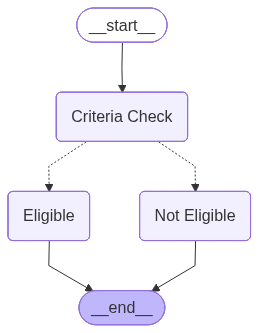

In [14]:
workflow

In [15]:
initial_state = {"age": 13}
print(workflow.invoke(initial_state)["result"])

Not Eligible to Vote
